<a href="https://colab.research.google.com/github/Mounika-ajh/Mounika-ajh/blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/insurance (1).csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.shape

(1338, 7)

In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [12]:
df['sex'].value_counts()
df['smoker'].value_counts()
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


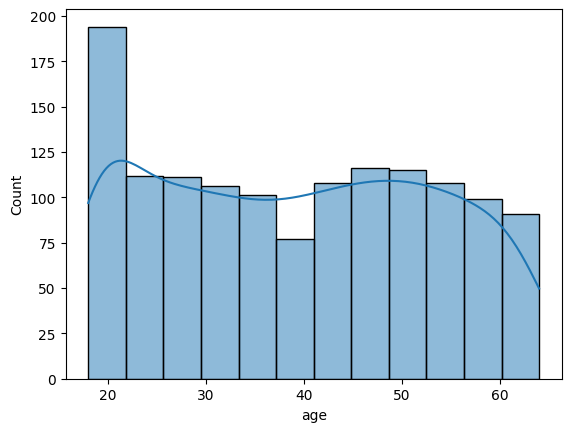

In [13]:
sns.histplot(df['age'], kde=True)
plt.show()

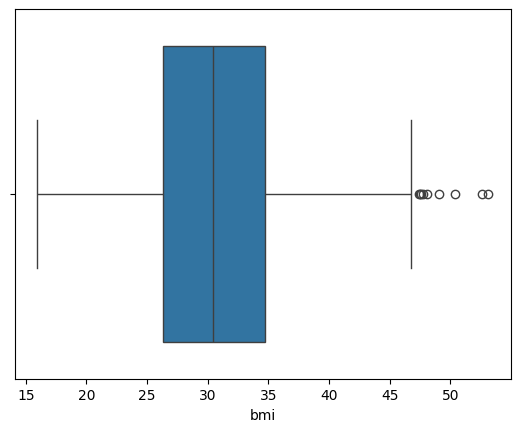

In [14]:
sns.boxplot(x=df['bmi'])
plt.show()

In [15]:
df['smoker'].value_counts(normalize=True)

,proportion
smoker,
no,0.795217
yes,0.204783


In [16]:
df['region'].value_counts()


,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [1]:
df.groupby('sex')['charges'].mean()

NameError: name 'df' is not defined

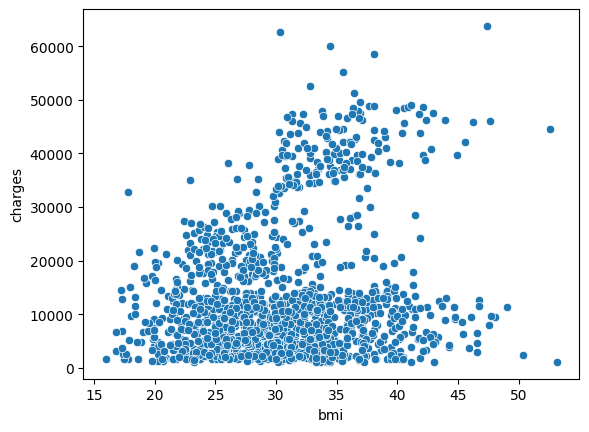

In [18]:
df[['bmi','charges']].corr()
sns.scatterplot(x='bmi', y='charges', data=df)
plt.show()

In [19]:
df.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8434.268298
yes,32050.231832


In [20]:
df.groupby(['sex','smoker'])['charges'].mean()

sex     smoker
female  no         8762.297300
        yes       30678.996276
male    no         8087.204731
        yes       33042.005975
Name: charges, dtype: float64

In [21]:
df[['children','charges']].corr()

,children,charges
children,1.000000,0.067998
charges,0.067998,1.000000


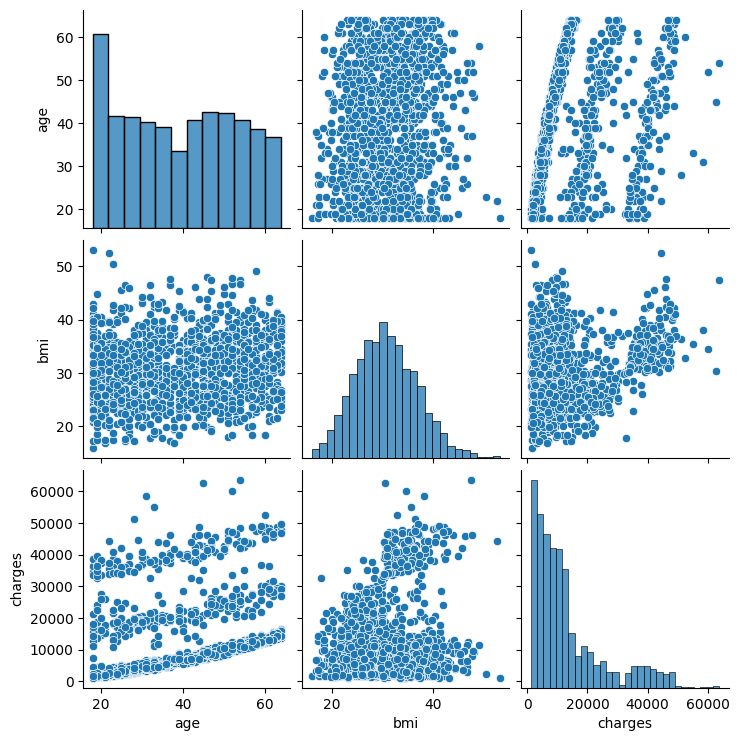

In [22]:
sns.pairplot(df[['age','bmi','charges']])
plt.show()

In [23]:
df.groupby(['age','sex','smoker'])['charges'].mean()

age  sex     smoker
18   female  no         3716.739021
             yes       26862.269925
     male    no         2695.672040
             yes       24779.460369
19   female  no         3879.902796
                           ...     
63   male    yes       47055.532100
64   female  no        15262.426207
             yes       37896.995563
     male    no        16280.409340
             yes       41131.146000
Name: charges, Length: 183, dtype: float64

In [24]:
df.groupby(['region','smoker'])['charges'].mean()

region     smoker
northeast  no         9165.531672
           yes       29673.536473
northwest  no         8556.463715
           yes       30192.003182
southeast  no         8032.216309
           yes       34844.996824
southwest  no         8019.284513
           yes       32269.063494
Name: charges, dtype: float64

In [25]:
df['region_smoker'] = df['region'] + "_" + df['smoker']
df.groupby('region_smoker')['charges'].mean()

,charges
region_smoker,
northeast_no,9165.531672
northeast_yes,29673.536473
northwest_no,8556.463715
northwest_yes,30192.003182
southeast_no,8032.216309
southeast_yes,34844.996824
southwest_no,8019.284513
southwest_yes,32269.063494


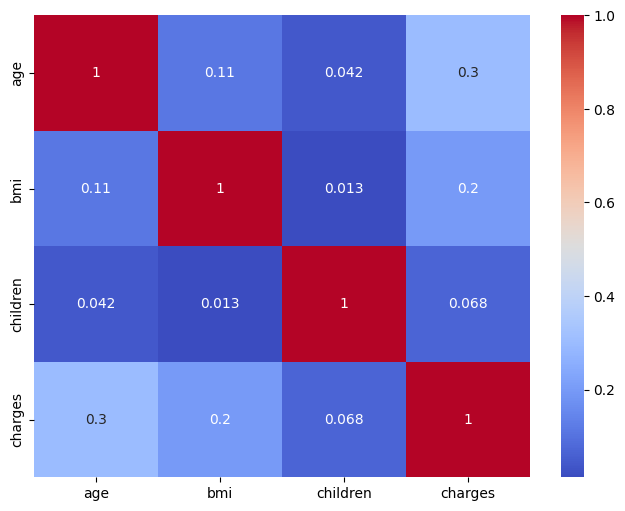

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [27]:
df['family_size'] = df['children'] + 1
df[['family_size','charges']].corr()

,family_size,charges
family_size,1.000000,0.067998
charges,0.067998,1.000000


In [28]:
bins = [18,30,50,65]
labels = ['Young Adult','Middle Age','Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

df.groupby('age_group')['charges'].mean()

/tmp/ipykernel_194/2672387496.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['charges'].mean()


,charges
age_group,
Young Adult,9822.837599
Middle Age,13280.774031
Senior,18084.987223
